In [17]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from celluloid import Camera

In [12]:
deg = np.pi/180
rad = 180/np.pi

def edm_simple_pendulum(t, y, g, L):
    theta, u = y
    dtheta_dt = u
    du_dt = -(g/L)*np.sin(theta)
    return [dtheta_dt, du_dt]

In [13]:
edm_simple_pendulum(1, [2,3], 4, 5)

[3, np.float64(-0.7274379414605454)]

In [14]:
ts = np.linspace(0, 10, 100)
Y0s = [40 * deg, 0]

sol = solve_ivp(
    edm_simple_pendulum, [ts[0], ts[-1]], Y0s, t_eval=ts, args = (9.8, 1.)
)
thetas = sol.y[0, :]
u = sol.y[1, :]

In [15]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 6.981e-01  6.662e-01 ...  1.579e-01  3.559e-01]
            [ 0.000e+00 -6.281e-01 ...  2.072e+00  1.818e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 224
     njev: 0
      nlu: 0

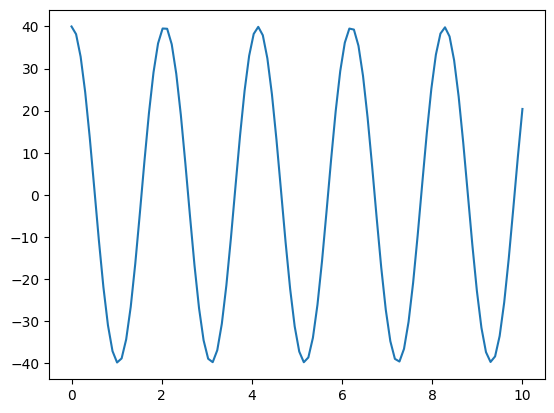

In [21]:
plt.plot(ts, thetas*rad)

In [24]:
ts = np.linspace(0, 10, 100)
Y0s = [70 * deg, 0]
g = 9.8
L = 1

sol = solve_ivp(
    edm_simple_pendulum, [ts[0], ts[-1]], Y0s, t_eval=ts, args = (g, L)
)

thetas = sol.y[0, :]
u = sol.y[1, :]

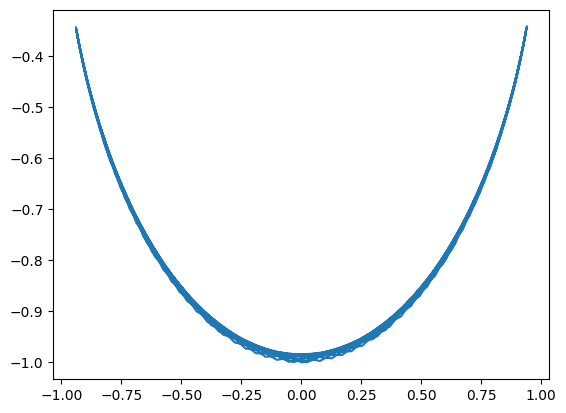

In [25]:
L = 1
xs = L * np.sin(thetas)
ys = -L * np.cos(thetas)

plt.plot(xs, ys)

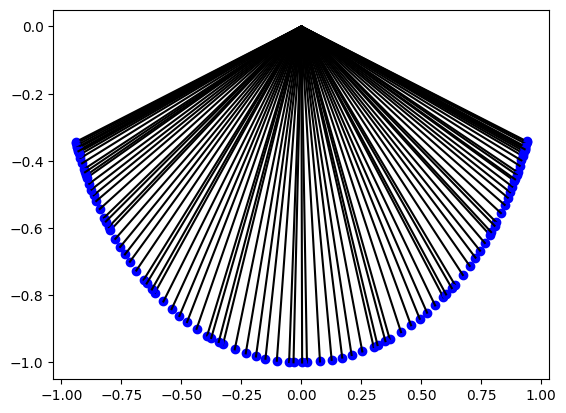

In [35]:
# Animationnn

fig = plt.figure()
camera = Camera(fig)

for i, t in enumerate(ts):
    plt.plot(xs[i], ys[i], "bo")
    plt.plot([0, xs[i]], [0, ys[i]], "k-")
    camera.snap()

In [36]:
from IPython.display import HTML
animation = camera.animate()
HTML(animation.to_jshtml())